In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = joblib.load(
    r'C:\Users\divya\Desktop\Team parakh\Parakh-task-5\cleaned_dataset.pkl')
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
0,0,0,0,0,1,1,1,1,0,1,...,9,0,6,0,0.0,0.0,0.0,0.0,2,1
1,2,0,0,0,1,1,1,0,1,1,...,6,0,5,12,0.0,0.0,0.0,0.0,2,0
2,3,1,0,0,0,0,0,0,0,0,...,7,1,0,21,1.0,0.0,0.0,0.0,1,1
5,3,0,0,0,1,0,1,1,0,0,...,5,1,3,15,0.0,1.0,0.0,0.0,1,0
6,1,1,0,0,0,0,0,0,0,0,...,6,3,0,6,0.0,0.0,0.0,0.0,1,3


In [3]:
x = df.drop('target_career', axis=1)
print("Number of features:", x.shape[1])
print("Number of students:", x.shape[0])

Number of features: 43
Number of students: 1399


In [4]:
scaler = joblib.load(
    r'C:\Users\divya\Desktop\Team parakh\standard_scaler.pkl')

In [5]:
x_scaled = scaler.transform(x)

In [6]:
x_scaled.shape

(1399, 43)

In [7]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

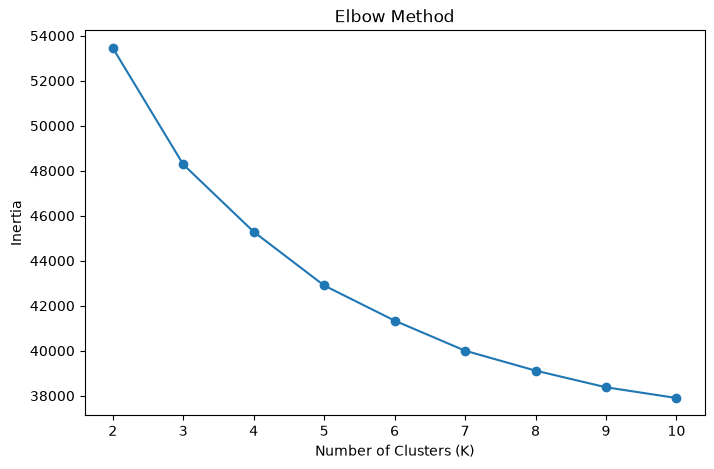

In [10]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),inertia,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [11]:
silhouette_scores = []
for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)    
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)    
    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.1342221947156853
K = 3 Silhouette Score = 0.12934353495598183
K = 4 Silhouette Score = 0.1216330884208721
K = 5 Silhouette Score = 0.12743689218625048
K = 6 Silhouette Score = 0.12862880607738603
K = 7 Silhouette Score = 0.12232071570134176
K = 8 Silhouette Score = 0.10837942848015861
K = 9 Silhouette Score = 0.10370237972937729
K = 10 Silhouette Score = 0.09766509137426607


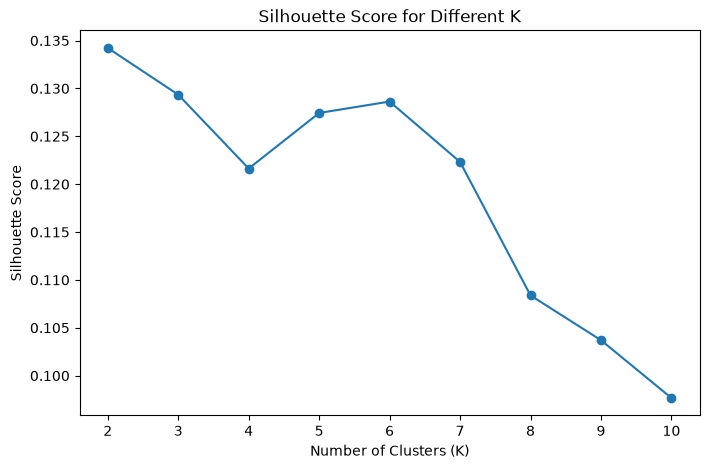

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),silhouette_scores,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.show()

In [15]:
optimal_k = 2

In [16]:
kmeans = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)

cluster_labels = kmeans.fit_predict(x_scaled)

In [17]:
df['cluster'] = cluster_labels
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score,cluster
0,0,0,0,0,1,1,1,1,0,1,...,0,6,0,0.0,0.0,0.0,0.0,2,1,0
1,2,0,0,0,1,1,1,0,1,1,...,0,5,12,0.0,0.0,0.0,0.0,2,0,0
2,3,1,0,0,0,0,0,0,0,0,...,1,0,21,1.0,0.0,0.0,0.0,1,1,1
5,3,0,0,0,1,0,1,1,0,0,...,1,3,15,0.0,1.0,0.0,0.0,1,0,0
6,1,1,0,0,0,0,0,0,0,0,...,3,0,6,0.0,0.0,0.0,0.0,1,3,1


In [18]:
print(df['cluster'].value_counts().sort_index())

cluster
0     330
1    1069
Name: count, dtype: int64


In [19]:
pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(x_scaled)

In [20]:
print(x_pca_2d.shape)

(1399, 2)


In [22]:
pca_df = pd.DataFrame(x_pca_2d,columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
pca_df.head()

,PC1,PC2,cluster
0,-5.207499,-2.374225,0
1,-5.382608,-2.009596,0
2,-0.200161,3.119080,1
3,-3.191002,-1.468741,0
4,1.904349,0.273568,1


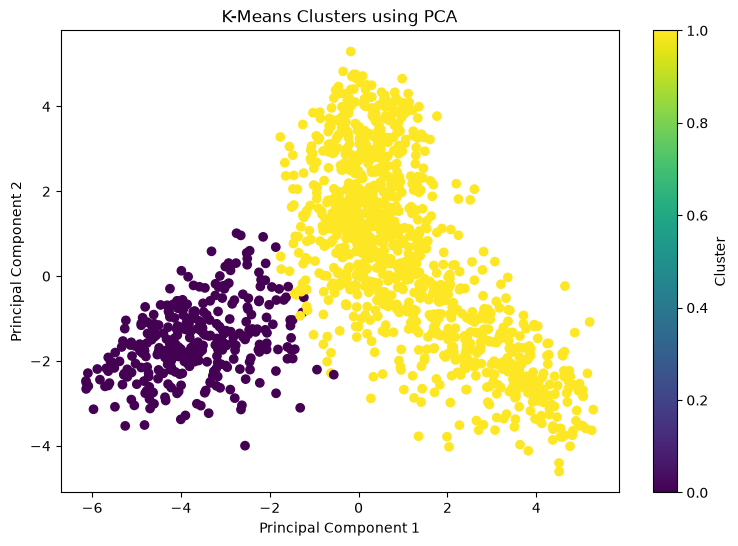

In [ ]:
plt.figure(figsize=(9,6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
)\\
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")
plt.colorbar(label="Cluster")
plt.show()

In [27]:
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
cluster_profile

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.239394,0.221212,0.242424,0.042424,0.806061,0.742424,0.554545,0.566667,0.203030,0.542424,...,7.490909,0.451515,3.827273,9.024242,0.175758,0.115152,0.151515,0.154545,2.054545,1.048485
1,1.148737,0.762395,0.144060,0.118803,0.034612,0.052385,0.048644,0.042095,0.036483,0.098223,...,8.526660,2.288120,0.721235,9.908326,0.165575,0.130964,0.140318,0.154350,1.112254,2.642657


In [28]:
joblib.dump(kmeans,r'C:\Users\divya\Desktop\Team parakh\kmeans_model.pkl')

['C:\\Users\\divya\\Desktop\\Team parakh\\kmeans_model.pkl']

In [29]:
joblib.dump(pca_2d,r'C:\Users\divya\Desktop\Team parakh\pca_2d.pkl')

['C:\\Users\\divya\\Desktop\\Team parakh\\pca_2d.pkl']